Graph Setup

In [5]:
import networkx as nx

G = nx.read_edgelist("data/CA-AstroPh.txt", comments="#", nodetype=int)

# --- Controllo e rimozione dei self-loop ---
n_self_loops = nx.number_of_selfloops(G)
print(f"Self-loop trovati: {n_self_loops}")

if n_self_loops > 0:
    G.remove_edges_from(nx.selfloop_edges(G))
    print(f"Self-loop rimossi. Nuovo numero di archi: {G.number_of_edges()}")

# G ripulito.
# --- Componente connessa più grande ---

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

Self-loop trovati: 60
Self-loop rimossi. Nuovo numero di archi: 198050


In [6]:
from algorithms.cost_functions import cost_random, cost_degree
from algorithms.variant.cs_greedy_new import cost_seeds_greedy
from algorithms.wtss import wtss
from algorithms.my_seeds import my_seeds
from algorithms.cascade import simulate_cascade

# Le due funzioni di costo, calcolate una sola volta su G_lcc
c1 = cost_random(G_lcc, low=1, high=21, seed=42)
c2 = cost_degree(G_lcc)

print(f"c1 - costo totale: {sum(c1.values())}, media: {sum(c1.values())/len(c1):.2f}")
print(f"c2 - costo totale: {sum(c2.values())}, media: {sum(c2.values())/len(c2):.2f}")

c1 - costo totale: 197720, media: 11.04
c2 - costo totale: 201526, media: 11.26


In [7]:
algorithms = {
    "Greedy-f1": lambda G, k, c: cost_seeds_greedy(G, k, c, "f1"),
    "Greedy-f2": lambda G, k, c: cost_seeds_greedy(G, k, c, "f2"),
    "Greedy-f3": lambda G, k, c: cost_seeds_greedy(G, k, c, "f3"),
    "WTSS":      lambda G, k, c: wtss(G, k, c),
    "My-Seeds":  lambda G, k, c: my_seeds(G, k, c),
}

percentages = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]

cost_scenarios = {
    "c1_random": c1,
    "c2_degree": c2,
}

k_values = {}
for cost_name, c in cost_scenarios.items():
    total_cost = sum(c.values())
    k_values[cost_name] = [round(p * total_cost) for p in percentages]
    print(f"{cost_name} (totale={total_cost}): k = {k_values[cost_name]}")

c1_random (totale=197720): k = [989, 1977, 3954, 9886, 19772, 39544]
c2_degree (totale=201526): k = [1008, 2015, 4031, 10076, 20153, 40305]


Esperimento 1

In [8]:
import time
import json
import os
import pandas as pd

# ============================================================
# ESPERIMENTO 1 — Variazione del budget k
# ============================================================

output_file = "results_experiment1.csv"

# Se il file esiste già, recupera i risultati precedenti.
# In questo modo, rilanciando la cella, non vengono ricalcolati
# gli esperimenti già completati.
if os.path.exists(output_file):
    results_df = pd.read_csv(output_file)
    results = results_df.to_dict("records")

    completed = {
        (row["cost_function"], row["algorithm"], float(row["percentage"]))
        for _, row in results_df.iterrows()
    }

    print(f"Risultati già presenti: {len(results)}")
else:
    results = []
    completed = set()


total_runs = len(cost_scenarios) * len(algorithms) * len(percentages)
run_number = len(completed)


for cost_name, c in cost_scenarios.items():

    total_cost = sum(c.values())

    print("\n" + "=" * 70)
    print(f"FUNZIONE DI COSTO: {cost_name}")
    print(f"Costo totale della rete: {total_cost}")
    print("=" * 70)

    for algorithm_name, algorithm in algorithms.items():

        print(f"\n--- {algorithm_name} ---")

        for percentage in percentages:

            key = (cost_name, algorithm_name, float(percentage))

            # Salta le esecuzioni già presenti nel CSV
            if key in completed:
                print(
                    f"[SKIP] k = {percentage * 100:g}% "
                    f"già calcolato"
                )
                continue

            k = round(percentage * total_cost)

            run_number += 1

            print(
                f"\n[{run_number}/{total_runs}] "
                f"{cost_name} | {algorithm_name} | "
                f"k = {percentage * 100:g}% ({k})"
            )

            # ------------------------------------------------
            # 1. Calcolo del seed set
            # ------------------------------------------------
            start = time.time()

            S = algorithm(G_lcc, k, c)

            runtime = time.time() - start

            # ------------------------------------------------
            # 2. Simulazione della Majority Cascade
            # ------------------------------------------------
            influenced = simulate_cascade(G_lcc, S)

            # ------------------------------------------------
            # 3. Statistiche
            # ------------------------------------------------
            seed_cost = sum(c[v] for v in S)
            seed_size = len(S)
            influenced_size = len(influenced)

            print(
                f"|S| = {seed_size} | "
                f"c(S) = {seed_cost}/{k} | "
                f"|Inf[G,S]| = {influenced_size} | "
                f"tempo = {runtime:.2f}s"
            )

            # ------------------------------------------------
            # 4. Salvataggio risultato
            # ------------------------------------------------
            result = {
                "cost_function": cost_name,
                "algorithm": algorithm_name,
                "percentage": percentage,
                "percentage_label": f"{percentage * 100:g}%",
                "k": k,
                "seed_size": seed_size,
                "seed_cost": seed_cost,
                "influenced_size": influenced_size,
                "runtime_seconds": runtime,

                # Salviamo anche i nodi del seed set:
                # serviranno negli Esperimenti 2 e 3.
                "seed_set": json.dumps(sorted(S))
            }

            results.append(result)
            completed.add(key)

            # Salvataggio incrementale dopo OGNI esecuzione
            pd.DataFrame(results).to_csv(output_file, index=False)


print("\n" + "=" * 70)
print("ESPERIMENTO 1 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)

results_df = pd.DataFrame(results)

display(
    results_df[
        [
            "cost_function",
            "algorithm",
            "percentage_label",
            "k",
            "seed_size",
            "seed_cost",
            "influenced_size",
            "runtime_seconds"
        ]
    ]
)

Risultati già presenti: 60

FUNZIONE DI COSTO: c1_random
Costo totale della rete: 197720

--- Greedy-f1 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- Greedy-f2 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- Greedy-f3 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- WTSS ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- My-Seeds ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già c

,cost_function,algorithm,percentage_label,k,seed_size,seed_cost,influenced_size,runtime_seconds
0,c1_random,Greedy-f1,0.5%,989,435,987,633,33.213625
1,c1_random,Greedy-f1,1%,1977,697,1973,1126,50.413544
2,c1_random,Greedy-f1,2%,3954,1128,3948,13582,79.704099
3,c1_random,Greedy-f1,5%,9886,2146,9873,14598,139.323867
4,c1_random,Greedy-f1,10%,19772,3696,19772,16530,224.584368
5,c1_random,Greedy-f1,20%,39544,6166,39540,17767,329.131108
6,c1_random,Greedy-f2,0.5%,989,388,989,540,123.590172
7,c1_random,Greedy-f2,1%,1977,640,1976,1071,217.109263
8,c1_random,Greedy-f2,2%,3954,1074,3953,13260,406.722128
9,c1_random,Greedy-f2,5%,9886,2133,9884,14352,917.681943


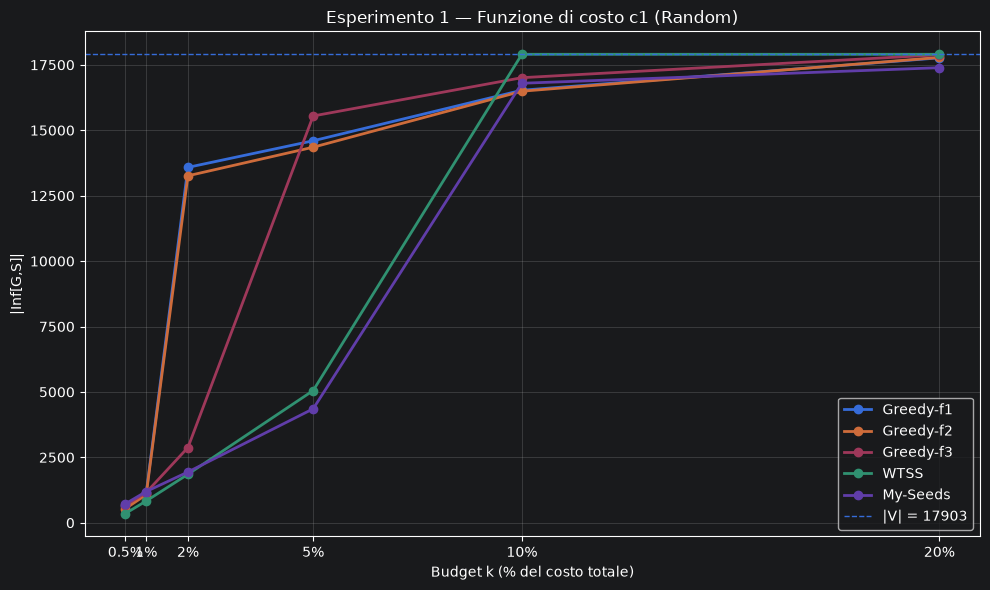

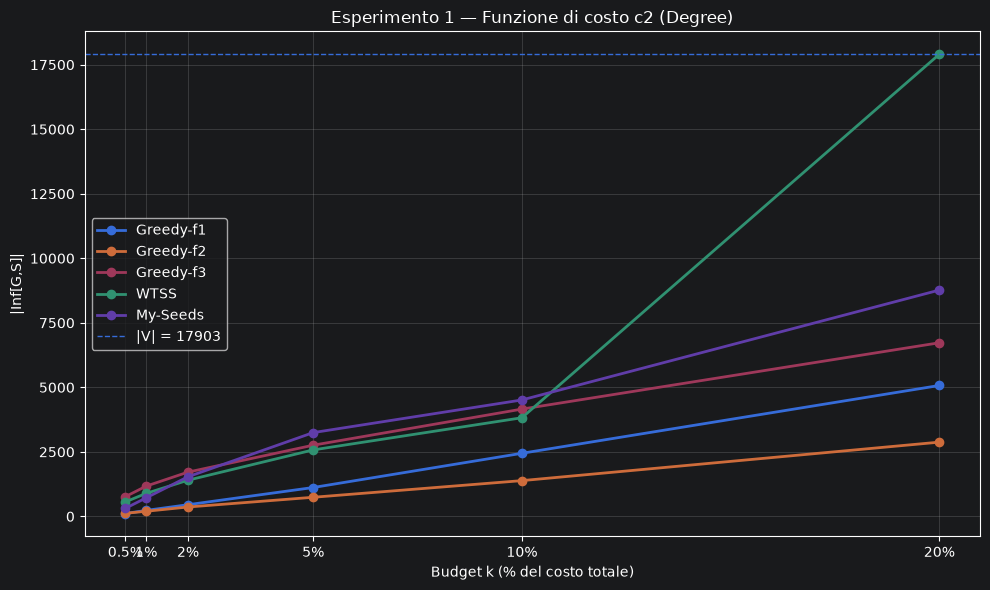

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GRAFICI ESPERIMENTO 1
# ============================================================

results_exp1 = pd.read_csv("results_experiment1.csv")

cost_titles = {
    "c1_random": "Esperimento 1 — Funzione di costo c1 (Random)",
    "c2_degree": "Esperimento 1 — Funzione di costo c2 (Degree)"
}

algorithm_order = [
    "Greedy-f1",
    "Greedy-f2",
    "Greedy-f3",
    "WTSS",
    "My-Seeds"
]

# Percentuali espresse come 0.5, 1, 2, 5, 10, 20
budget_ticks = sorted(results_exp1["percentage"].unique() * 100)


for cost_name in ["c1_random", "c2_degree"]:

    df_cost = results_exp1[
        results_exp1["cost_function"] == cost_name
    ]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithm_order:

        df_alg = df_cost[
            df_cost["algorithm"] == algorithm
        ].sort_values("percentage")

        plt.plot(
            df_alg["percentage"] * 100,
            df_alg["influenced_size"],
            marker="o",
            linewidth=2,
            label=algorithm
        )

    # Numero massimo di nodi potenzialmente attivabili
    plt.axhline(
        y=G_lcc.number_of_nodes(),
        linestyle="--",
        linewidth=1,
        label=f"|V| = {G_lcc.number_of_nodes()}"
    )

    plt.title(cost_titles[cost_name])
    plt.xlabel("Budget k (% del costo totale)")
    plt.ylabel("|Inf[G,S]|")

    plt.xticks(
        budget_ticks,
        [f"{x:g}%" for x in budget_ticks]
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Salvataggio del grafico
    plt.savefig(
        f"experiment1_{cost_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Esperimento 2

In [17]:
import pandas as pd
import json
import random

# ============================================================
# ESPERIMENTO 2 — Robustezza alla rimozione casuale di archi
# ============================================================

# Budget rappresentativo scelto dall'Esperimento 1.
# MODIFICARE questo valore dopo aver analizzato i risultati.
k_star_percentage = 0.10       # esempio: 5%

# Percentuali di archi da rimuovere
edge_removal_percentages = [0.01, 0.05, 0.10, 0.20]

# Seed per rendere riproducibile la perturbazione casuale
random_seed = 42

input_file = "results_experiment1.csv"
output_file = "results_experiment2.csv"


# ------------------------------------------------------------
# 1. Caricamento dei risultati dell'Esperimento 1
# ------------------------------------------------------------

exp1_df = pd.read_csv(input_file)

# Seleziona soltanto i risultati corrispondenti a k*
exp1_kstar = exp1_df[
    (exp1_df["percentage"] - k_star_percentage).abs() < 1e-12
].copy()

expected_results = len(cost_scenarios) * len(algorithms)

if len(exp1_kstar) != expected_results:
    raise ValueError(
        f"Per k*={k_star_percentage * 100:g}% erano attesi "
        f"{expected_results} seed set, ma ne sono stati trovati "
        f"{len(exp1_kstar)}."
    )

print(
    f"k* selezionato: {k_star_percentage * 100:g}% "
    f"({len(exp1_kstar)} seed set recuperati)"
)


# ------------------------------------------------------------
# 2. Funzione per creare un grafo perturbato
#
# ------------------------------------------------------------

def remove_random_edges_no_isolates(G, percentage, seed):
    """
    Rimuove casualmente una percentuale degli archi di G evitando
    di creare nodi isolati.

    Un arco (u, v) viene rimosso soltanto se entrambi gli estremi
    hanno grado > 1 al momento della rimozione.

    Il grafo può eventualmente suddividersi in più componenti,
    ma nessun nodo rimane con grado zero.
    """

    rng = random.Random(seed)

    G_removed = G.copy()

    n_remove = round(
        percentage * G.number_of_edges()
    )

    edges = list(G.edges())
    rng.shuffle(edges)

    removed_edges = []

    for u, v in edges:

        if len(removed_edges) >= n_remove:
            break

        # La rimozione non deve isolare u o v
        if (
            G_removed.degree(u) > 1
            and G_removed.degree(v) > 1
        ):
            G_removed.remove_edge(u, v)
            removed_edges.append((u, v))

    if len(removed_edges) < n_remove:
        raise RuntimeError(
            f"È stato possibile rimuovere soltanto "
            f"{len(removed_edges)} archi su {n_remove} richiesti."
        )

    # Controllo finale
    n_isolates = nx.number_of_isolates(G_removed)

    if n_isolates != 0:
        raise RuntimeError(
            f"La perturbazione ha prodotto {n_isolates} nodi isolati."
        )

    print(
        f"{percentage * 100:g}%: "
        f"{len(removed_edges)} archi rimossi | "
        f"componenti = {nx.number_connected_components(G_removed)} | "
        f"nodi isolati = {n_isolates}"
    )

    return G_removed, removed_edges


# ------------------------------------------------------------
# 3. Generazione dei grafi perturbati
#
# IMPORTANTE:
# per ogni percentuale viene creato UN SOLO grafo perturbato,
# riutilizzato poi per tutti gli algoritmi e per entrambi i costi.
# ------------------------------------------------------------

perturbed_graphs = {}

for i, percentage in enumerate(edge_removal_percentages):

    G_removed, removed_edges = remove_random_edges_no_isolates(
        G_lcc,
        percentage,
        seed=random_seed + i
    )

    perturbed_graphs[percentage] = {
        "graph": G_removed,
        "removed_edges": removed_edges
    }


# ------------------------------------------------------------
# 4. Esecuzione dell'Esperimento 2
# ------------------------------------------------------------

results_exp2 = []

total_runs = (
    len(edge_removal_percentages)
    * len(cost_scenarios)
    * len(algorithms)
)

run_number = 0


for percentage in edge_removal_percentages:

    G_removed = perturbed_graphs[percentage]["graph"]
    removed_edges = perturbed_graphs[percentage]["removed_edges"]

    print("\n" + "=" * 70)
    print(
        f"RIMOZIONE ARCHI: {percentage * 100:g}% "
        f"({len(removed_edges)} archi)"
    )
    print("=" * 70)

    for _, row in exp1_kstar.iterrows():

        run_number += 1

        cost_name = row["cost_function"]
        algorithm_name = row["algorithm"]

        # Recupero del seed set calcolato nell'Esperimento 1
        S = set(json.loads(row["seed_set"]))

        # ----------------------------------------------------
        # Simulazione della cascata sul grafo perturbato
        # ----------------------------------------------------

        influenced = simulate_cascade(G_removed, S)

        influenced_size = len(influenced)

        print(
            f"[{run_number}/{total_runs}] "
            f"{cost_name} | {algorithm_name} | "
            f"|S|={len(S)} | "
            f"|Inf[G',S]|={influenced_size}"
        )

        results_exp2.append({
            "cost_function": cost_name,
            "algorithm": algorithm_name,

            "k_star_percentage": k_star_percentage,
            "k_star_percentage_label":
                f"{k_star_percentage * 100:g}%",

            "edge_removal_percentage": percentage,
            "edge_removal_label":
                f"{percentage * 100:g}%",

            "removed_edges": len(removed_edges),
            "remaining_edges": G_removed.number_of_edges(),

            "seed_size": len(S),

            "influenced_original":
                row["influenced_size"],

            "influenced_after_removal":
                influenced_size,

            "is_connected": nx.is_connected(G_removed),

            "number_of_components":
                nx.number_connected_components(G_removed),

            "isolated_nodes":
                nx.number_of_isolates(G_removed),

            # Per riproducibilità salviamo anche quali archi
            # sono stati effettivamente rimossi
            "removed_edge_list":
                json.dumps(removed_edges)
        })


# ------------------------------------------------------------
# 5. Salvataggio CSV
# ------------------------------------------------------------

results_exp2_df = pd.DataFrame(results_exp2)

results_exp2_df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ESPERIMENTO 2 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)

display(
    results_exp2_df[
        [
            "cost_function",
            "algorithm",
            "edge_removal_label",
            "removed_edges",
            "seed_size",
            "influenced_original",
            "influenced_after_removal",
            "is_connected",
            "number_of_components",
            "isolated_nodes"
        ]
    ]
)

k* selezionato: 10% (10 seed set recuperati)
1%: 1970 archi rimossi | componenti = 2 | nodi isolati = 0
5%: 9849 archi rimossi | componenti = 6 | nodi isolati = 0
10%: 19697 archi rimossi | componenti = 11 | nodi isolati = 0
20%: 39394 archi rimossi | componenti = 24 | nodi isolati = 0

RIMOZIONE ARCHI: 1% (1970 archi)
[1/40] c1_random | Greedy-f1 | |S|=3696 | |Inf[G',S]|=16539
[2/40] c1_random | Greedy-f2 | |S|=3727 | |Inf[G',S]|=16501
[3/40] c1_random | Greedy-f3 | |S|=3806 | |Inf[G',S]|=16968
[4/40] c1_random | WTSS | |S|=3264 | |Inf[G',S]|=17894
[5/40] c1_random | My-Seeds | |S|=4200 | |Inf[G',S]|=16845
[6/40] c2_degree | Greedy-f1 | |S|=1807 | |Inf[G',S]|=2463
[7/40] c2_degree | Greedy-f2 | |S|=1327 | |Inf[G',S]|=1389
[8/40] c2_degree | Greedy-f3 | |S|=2666 | |Inf[G',S]|=4176
[9/40] c2_degree | WTSS | |S|=3289 | |Inf[G',S]|=3825
[10/40] c2_degree | My-Seeds | |S|=4236 | |Inf[G',S]|=4504

RIMOZIONE ARCHI: 5% (9849 archi)
[11/40] c1_random | Greedy-f1 | |S|=3696 | |Inf[G',S]|=16618


,cost_function,algorithm,edge_removal_label,removed_edges,seed_size,influenced_original,influenced_after_removal,is_connected,number_of_components,isolated_nodes
0,c1_random,Greedy-f1,1%,1970,3696,16530,16539,False,2,0
1,c1_random,Greedy-f2,1%,1970,3727,16492,16501,False,2,0
2,c1_random,Greedy-f3,1%,1970,3806,17009,16968,False,2,0
3,c1_random,WTSS,1%,1970,3264,17903,17894,False,2,0
4,c1_random,My-Seeds,1%,1970,4200,16796,16845,False,2,0
5,c2_degree,Greedy-f1,1%,1970,1807,2445,2463,False,2,0
6,c2_degree,Greedy-f2,1%,1970,1327,1386,1389,False,2,0
7,c2_degree,Greedy-f3,1%,1970,2666,4157,4176,False,2,0
8,c2_degree,WTSS,1%,1970,3289,3822,3825,False,2,0
9,c2_degree,My-Seeds,1%,1970,4236,4511,4504,False,2,0


Esperimento 3

In [18]:
import pandas as pd
import json
import random

# ============================================================
# ESPERIMENTO 3 — Robustezza alla rimozione casuale di nodi
# ============================================================

# Deve essere lo stesso k* scelto per l'Esperimento 2
k_star_percentage = 0.10       # MODIFICARE dopo Esperimento 1

# Percentuali di nodi da rimuovere
node_removal_percentages = [0.01, 0.05, 0.10, 0.20]

# Seed per rendere riproducibile la perturbazione
random_seed = 42

input_file = "results_experiment1.csv"
output_file = "results_experiment3.csv"


# ------------------------------------------------------------
# 1. Caricamento dei risultati dell'Esperimento 1
# ------------------------------------------------------------

exp1_df = pd.read_csv(input_file)

exp1_kstar = exp1_df[
    (exp1_df["percentage"] - k_star_percentage).abs() < 1e-12
].copy()

expected_results = len(cost_scenarios) * len(algorithms)

if len(exp1_kstar) != expected_results:
    raise ValueError(
        f"Per k*={k_star_percentage * 100:g}% erano attesi "
        f"{expected_results} seed set, ma ne sono stati trovati "
        f"{len(exp1_kstar)}."
    )

print(
    f"k* selezionato: {k_star_percentage * 100:g}% "
    f"({len(exp1_kstar)} seed set recuperati)"
)


# ------------------------------------------------------------
# 2. Generazione dei grafi perturbati
# ------------------------------------------------------------

nodes = list(G_lcc.nodes())

perturbed_graphs_nodes = {}

for i, percentage in enumerate(node_removal_percentages):

    n_remove = round(percentage * len(nodes))

    rng = random.Random(random_seed + i)

    removed_nodes = rng.sample(nodes, n_remove)

    G_removed = G_lcc.copy()
    G_removed.remove_nodes_from(removed_nodes)

    # Informazioni strutturali dopo la perturbazione
    n_components = nx.number_connected_components(G_removed)

    largest_component_size = max(
        len(component)
        for component in nx.connected_components(G_removed)
    )

    print(
        f"{percentage * 100:g}%: "
        f"{n_remove} nodi rimossi | "
        f"nodi rimanenti = {G_removed.number_of_nodes()} | "
        f"componenti = {n_components} | "
        f"LCC = {largest_component_size}"
    )

    perturbed_graphs_nodes[percentage] = {
        "graph": G_removed,
        "removed_nodes": removed_nodes,
        "n_components": n_components,
        "largest_component_size": largest_component_size
    }


# ------------------------------------------------------------
# 3. Esecuzione dell'Esperimento 3
# ------------------------------------------------------------

results_exp3 = []

total_runs = (
    len(node_removal_percentages)
    * len(cost_scenarios)
    * len(algorithms)
)

run_number = 0


for percentage in node_removal_percentages:

    data = perturbed_graphs_nodes[percentage]

    G_removed = data["graph"]
    removed_nodes = set(data["removed_nodes"])

    print("\n" + "=" * 70)
    print(
        f"RIMOZIONE NODI: {percentage * 100:g}% "
        f"({len(removed_nodes)} nodi)"
    )
    print("=" * 70)

    for _, row in exp1_kstar.iterrows():

        run_number += 1

        cost_name = row["cost_function"]
        algorithm_name = row["algorithm"]

        # ----------------------------------------------------
        # Seed set originale calcolato sull'intero G
        # ----------------------------------------------------

        S_original = set(json.loads(row["seed_set"]))

        # ----------------------------------------------------
        # Alcuni seed potrebbero essere stati rimossi.
        #
        # NON vengono sostituiti:
        # il seed set sopravvissuto è semplicemente S \ R.
        # ----------------------------------------------------

        S_surviving = S_original - removed_nodes

        removed_seed_count = len(S_original) - len(S_surviving)

        # ----------------------------------------------------
        # Simulazione della cascata sul grafo perturbato
        # ----------------------------------------------------

        influenced = simulate_cascade(
            G_removed,
            S_surviving
        )

        influenced_size = len(influenced)

        # Percentuale dei nodi ancora presenti raggiunta
        influence_fraction = (
            influenced_size / G_removed.number_of_nodes()
            if G_removed.number_of_nodes() > 0
            else 0
        )

        print(
            f"[{run_number}/{total_runs}] "
            f"{cost_name} | {algorithm_name} | "
            f"|S originale|={len(S_original)} | "
            f"seed rimossi={removed_seed_count} | "
            f"|S'|={len(S_surviving)} | "
            f"|Inf[G',S']|={influenced_size}"
        )

        results_exp3.append({

            "cost_function": cost_name,
            "algorithm": algorithm_name,

            "k_star_percentage": k_star_percentage,
            "k_star_percentage_label":
                f"{k_star_percentage * 100:g}%",

            "node_removal_percentage": percentage,
            "node_removal_label":
                f"{percentage * 100:g}%",

            "removed_nodes": len(removed_nodes),
            "remaining_nodes": G_removed.number_of_nodes(),

            "original_seed_size": len(S_original),
            "surviving_seed_size": len(S_surviving),
            "removed_seed_count": removed_seed_count,

            "influenced_original":
                row["influenced_size"],

            "influenced_after_removal":
                influenced_size,

            "influence_fraction_remaining":
                influence_fraction,

            "connected":
                nx.is_connected(G_removed),

            "number_of_components":
                data["n_components"],

            "largest_component_size":
                data["largest_component_size"],

            # Salviamo i nodi effettivamente rimossi
            # per rendere riproducibile l'esperimento
            "removed_node_list":
                json.dumps(sorted(removed_nodes))
        })


# ------------------------------------------------------------
# 4. Salvataggio CSV
# ------------------------------------------------------------

results_exp3_df = pd.DataFrame(results_exp3)

results_exp3_df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ESPERIMENTO 3 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)


display(
    results_exp3_df[
        [
            "cost_function",
            "algorithm",
            "node_removal_label",
            "removed_nodes",
            "original_seed_size",
            "removed_seed_count",
            "surviving_seed_size",
            "influenced_original",
            "influenced_after_removal",
            "number_of_components",
            "largest_component_size"
        ]
    ]
)

k* selezionato: 10% (10 seed set recuperati)
1%: 179 nodi rimossi | nodi rimanenti = 17724 | componenti = 11 | LCC = 17713
5%: 895 nodi rimossi | nodi rimanenti = 17008 | componenti = 64 | LCC = 16917
10%: 1790 nodi rimossi | nodi rimanenti = 16113 | componenti = 120 | LCC = 15949
20%: 3581 nodi rimossi | nodi rimanenti = 14322 | componenti = 309 | LCC = 13809

RIMOZIONE NODI: 1% (179 nodi)
[1/40] c1_random | Greedy-f1 | |S originale|=3696 | seed rimossi=41 | |S'|=3655 | |Inf[G',S']|=16334
[2/40] c1_random | Greedy-f2 | |S originale|=3727 | seed rimossi=42 | |S'|=3685 | |Inf[G',S']|=16296
[3/40] c1_random | Greedy-f3 | |S originale|=3806 | seed rimossi=41 | |S'|=3765 | |Inf[G',S']|=16824
[4/40] c1_random | WTSS | |S originale|=3264 | seed rimossi=29 | |S'|=3235 | |Inf[G',S']|=17710
[5/40] c1_random | My-Seeds | |S originale|=4200 | seed rimossi=44 | |S'|=4156 | |Inf[G',S']|=16594
[6/40] c2_degree | Greedy-f1 | |S originale|=1807 | seed rimossi=22 | |S'|=1785 | |Inf[G',S']|=2422
[7/40] 

,cost_function,algorithm,node_removal_label,removed_nodes,original_seed_size,removed_seed_count,surviving_seed_size,influenced_original,influenced_after_removal,number_of_components,largest_component_size
0,c1_random,Greedy-f1,1%,179,3696,41,3655,16530,16334,11,17713
1,c1_random,Greedy-f2,1%,179,3727,42,3685,16492,16296,11,17713
2,c1_random,Greedy-f3,1%,179,3806,41,3765,17009,16824,11,17713
3,c1_random,WTSS,1%,179,3264,29,3235,17903,17710,11,17713
4,c1_random,My-Seeds,1%,179,4200,44,4156,16796,16594,11,17713
5,c2_degree,Greedy-f1,1%,179,1807,22,1785,2445,2422,11,17713
6,c2_degree,Greedy-f2,1%,179,1327,14,1313,1386,1369,11,17713
7,c2_degree,Greedy-f3,1%,179,2666,24,2642,4157,4128,11,17713
8,c2_degree,WTSS,1%,179,3289,31,3258,3822,3790,11,17713
9,c2_degree,My-Seeds,1%,179,4236,38,4198,4511,4472,11,17713
